## Setup

In [12]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("data.csv")

# rename columns
name_dict = {
    'What gender do you identify as?': 'Gender',
    'How beneficial do you see the use of AI in these fields? [Therapists]': 'BenTher',
    'How beneficial do you see the use of AI in these fields? [Companionship]': 'BenComp',
    'In which areas do you find AI helpful in your workflow?  [Personal Advice / Therapy]': 'HelpTher',
    'In which areas do you find AI helpful in your workflow?  [Companionship]': 'HelpComp'
}
df = df.rename(columns=name_dict)

# specific columns for hypothesis 3
df_trim = df[['Gender', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']].copy()

# clean sentiment cols
sent_cols = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']
for col in sent_cols: df_trim[col] = df_trim[col].astype(str).str.extract(r'(\d+)').astype(float)

# drop missing data
df_trim = df_trim.dropna()

# add Gender_Num column for correlation: Male 0, Female 1, other 2
gendermap = {'Male': 0, 'Female': 1}
df_trim['Gender_Num'] = df_trim['Gender'].map(gendermap).fillna(2).astype(int)

# create average sentiment column
sentiment_cols = ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']
df_trim['Average_Sentiment'] = df_trim[sentiment_cols].mean(axis=1)

Correlation:              Gender_Num   BenTher   BenComp  HelpTher  HelpComp
Gender_Num    1.000000 -0.154003 -0.114914 -0.139424 -0.131512
BenTher      -0.154003  1.000000  0.672241  0.510502  0.459832
BenComp      -0.114914  0.672241  1.000000  0.548089  0.562256
HelpTher     -0.139424  0.510502  0.548089  1.000000  0.825998
HelpComp     -0.131512  0.459832  0.562256  0.825998  1.000000


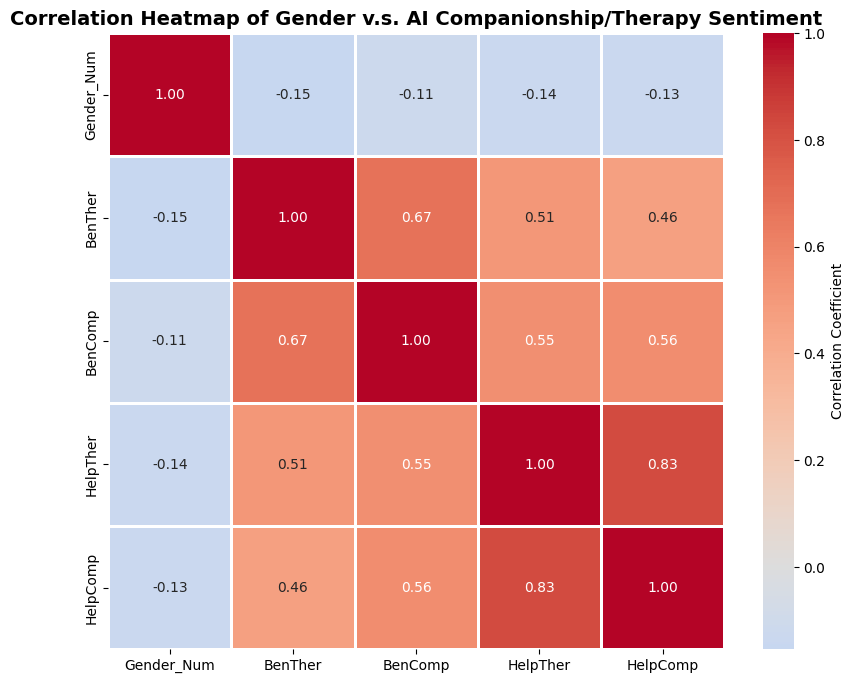

Full Correlation:              Gender_Num   BenTher   BenComp  HelpTher  HelpComp
Gender_Num    1.000000 -0.154003 -0.114914 -0.139424 -0.131512
BenTher      -0.154003  1.000000  0.672241  0.510502  0.459832
BenComp      -0.114914  0.672241  1.000000  0.548089  0.562256
HelpTher     -0.139424  0.510502  0.548089  1.000000  0.825998
HelpComp     -0.131512  0.459832  0.562256  0.825998  1.000000
Gender Correlation:               BenTher   BenComp  HelpTher  HelpComp
Gender_Num -0.154003 -0.114914 -0.139424 -0.131512


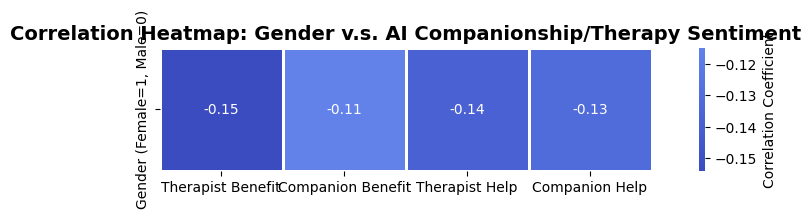

In [ ]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
# numeric_df = df.select_dtypes(include=[np.number])
df_num = df_trim[['Gender_Num', 'BenTher', 'BenComp', 'HelpTher', 'HelpComp']]

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
r = df_num.corr()
print(f"Correlation: ", r)

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap of Gender v.s. AI Companionship/Therapy Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

# Create a correlation heatmap to visualize relationships between all numeric variables

# correlation for gender
gender_r = r.loc[['Gender_Num'], ['BenTher', 'BenComp', 'HelpTher', 'HelpComp']]
print(f"Gender Correlation: ", gender_r)

gender_r.index = ['Gender (Female=1, Male=0)']
gender_r.columns = ['Therapist Benefit', 'Companion Benefit', 'Therapist Help', 'Companion Help']

# Set figure size for better readability
plt.figure(figsize=(10, 2))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(gender_r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap: Gender v.s. AI Companionship/Therapy Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.tight_layout()
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

## Visualization 1 - Correlation Heatmap

# Hypothesis 3
Null Hypothesis: College student’s frequency of use of AI and student sentiment towards AI generated content being in their social media feed are independent.

Hypothesis: Predominantly males find Ai to be beneficial in therapeutic and companionship issues.

dependent variable: correlation between frequency of AI use and sentiment about 

independent variables: Feelings about AI generated content in social media feed and frequency of AI usage

## Visualization 2 - Stacked Bar Chart

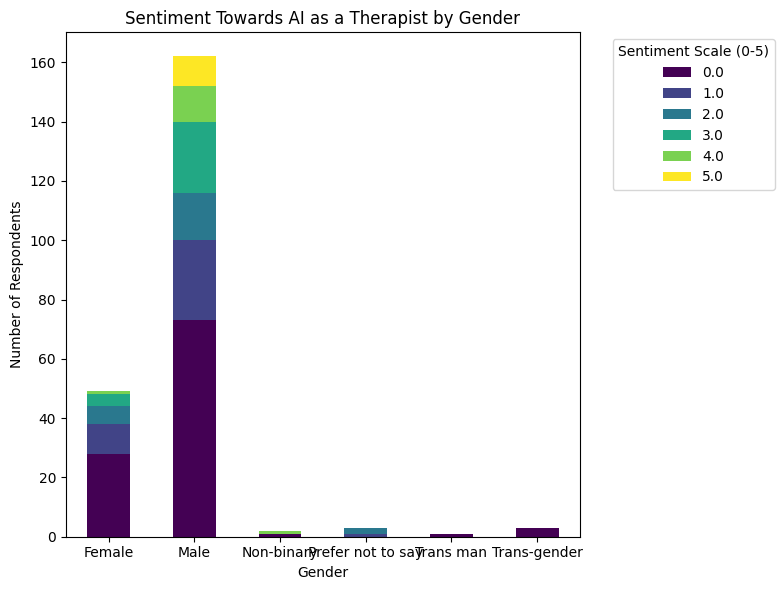

In [14]:
# cross-tab of Gender vs AI Therapy
crosstab_ther = pd.crosstab(df_trim['Gender'], df_trim['BenTher'])

# plotting
crosstab_ther.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')

plt.title('Sentiment Towards AI as a Therapist by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.legend(title='Sentiment Scale (0-5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chi-Square Test

Null Hypothesis: 

Alternate Hypothesis: 

In [ ]:
# create contingency table
contingency_table = pd.crosstab(df_trim['Gender'], df_trim['Average_Sentiment'])

# use contingency to run chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# print statistic
print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion: ")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: ")

Chi-Square Statistic: 51.84
P-value: 0.9999

Result: Fail to reject the Null Hypothesis.
Conclusion: 
